## Part 1



Issues:
- Kessler Syndrome (https://aquarid.physics.uwo.ca/kessler/Kessler%20Syndrome-AAS%20Paper.pdf)
- Rocket Launches - CO2 impact

Falcon 9 Rocket (https://sma.nasa.gov/LaunchVehicle/assets/spacex-falcon-9-data-sheet.pdf)

Copilot says:

A single SpaceX Falcon 9 launch uses approximately 507,500 kilograms (about 507.5 metric tonnes) of propellant, which consists of:

RP-1 (rocket-grade kerosene): ~112,184 kg
Liquid Oxygen (LOX): ~395,316 kg

This total is based on the Falcon 9 Full Thrust (Block 5) version, which is the current operational variant. The rocket is a two-stage launch vehicle, and both stages use RP-1 and LOX as propellants.
Breakdown by Stage

First Stage:

Propellant mass: ~395,700 kg
Burn time: ~162 seconds
Engines: 9 Merlin 1D


Second Stage:

Propellant mass: ~92,670 kg
Burn time: ~397 seconds
Engine: 1 Merlin Vacuum



These figures are derived from technical specifications and performance analyses. [wevolver.com]
Environmental Impact
Each Falcon 9 launch emits approximately 336,552 kg of CO₂, based on the combustion of RP-1 kerosene. [championtraveler.com]
Sources

Wevolver Falcon 9 Block 5 Specs [wevolver.com]
Champion Traveler CO₂ Analysis [championtraveler.com]
Wikipedia Falcon 9 Overview [en.wikipedia.org]

As of October 2025, SpaceX typically launches 28 Starlink satellites per Falcon 9 mission. [extremetech.com], [arstechnica.com], [msn.com]
This number has decreased over time due to the satellites becoming larger and more capable. Earlier in the Starlink program (around 2019–2020), Falcon 9 launches carried up to 60 satellites per flight. However, the current V2 Mini satellites are more advanced and heavier, which limits the number that can be carried per launch.

https://www.extremetech.com/aerospace/spacex-sends-10000th-starlink-satellite-into-orbit-with-latest-falcon-9




 D.J. Kessler and B.G. Cour-Palais, "Collision Frequency of Artificial Satellites: The Creation of a Debris Belt", Journal of Geophysical Research, Vol. 83, No. A6, pp. 2637-2646, June 1, 1978. 
Available at: https://www.freelists.org/archives/arocket/05-2025/pdfhf1FIX9bCw.pdf
Accessed 22/10/2025




## Code for Graphs below

In [1]:
# Install Requirements Using Pip
# %pip install -r requirements.txt

%pip install requests pandas numpy matplotlib seaborn plotly cartopy geopandas geopy pycountry scikit-learn lifelines networkX holoviews IPython
 

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard Libraries
import json
import random
from datetime import datetime
import sys

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# GeoPy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Pycountry 
import pycountry

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Load Cleaned Dataset

In [3]:
sdf = pd.read_csv('../../datasets/cleaned_engineered_sdf.csv')
#sdf = pd.read_csv('https://datascience.daemonchild.com/year2/dat5001/pres1/datasets/cleaned_engineered_sdf.csv')


## Define Palette

These graphs will end up in the PowerPoint presentation. This is the colour palette.

In [4]:

graph_palette = {
  "foreground": {
    "gold": "#FFBD02",
    "steelBlue": "#4977AA",
    "burntOrange": "#D94F00",
    "skyBlue": "#7EC8E3",
    "slateGrey": "#3E4A58",
    "green": "#087616",
    "lightGrey":"#A9A9A9"   
  },
  "background": {
    "darkBlue": "#0F1A37",
    "navyBlue": "#192B4D",
    "midnightBlue": "#121F36",
    "charcoal": "#1E2A3A"
  }
}


Create a graduated scale for maps and/or heatmaps

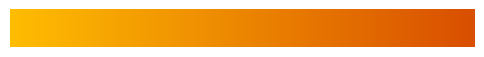

In [5]:

# Create a linear colormap
cmap_gold_orange = mcolors.LinearSegmentedColormap.from_list("GoldToSteelBlue", [graph_palette['foreground']['gold'], graph_palette['foreground']['burntOrange']])

# --- Example: visualize the gradient ---
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)

ax.imshow(gradient, aspect="auto", cmap=cmap_gold_orange )
ax.set_axis_off()
plt.show()


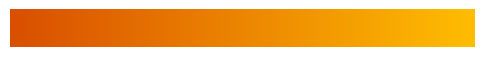

In [6]:

# Create a linear colormap
cmap_orange_gold = mcolors.LinearSegmentedColormap.from_list("BurntOrangetoGold", [graph_palette['foreground']['burntOrange'], graph_palette['foreground']['gold']])

# --- Example: visualize the gradient ---
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)

ax.imshow(gradient, aspect="auto", cmap=cmap_orange_gold)
ax.set_axis_off()
plt.show()

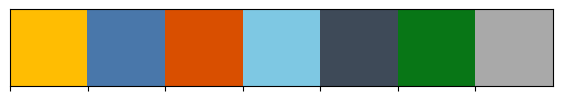

In [7]:
# Background
bg = graph_palette['background']['darkBlue']

# Extract foreground colours
foreground_colors = list(graph_palette["foreground"].values())
background_colors = list(graph_palette["background"].values())

# Create a Seaborn palette
sns_palette = sns.color_palette(foreground_colors)

# Optional: Set as default palette
sns.set_palette(sns_palette)

# Preview the palette
sns.palplot(sns_palette)
plt.show()

In [8]:
sdf.shape

(66560, 44)

In [9]:
sdf.columns

Index(['Apogee', 'Class', 'CosparID', 'Country', 'Country Code', 'Decay Date',
       'Decay Decade', 'Decay Month', 'Decay Month No', 'Decay Year',
       'Diameter', 'In Orbit', 'Launch Date', 'Launch Decade', 'Launch Month',
       'Launch Month No', 'Launch Year', 'Length', 'Lifespan Days',
       'Lifespan Months', 'Lifespan Years', 'Manufacturer Code',
       'Manufacturer Latitude', 'Manufacturer Long Name',
       'Manufacturer Longitude', 'Manufacturer Parent',
       'Manufacturer Short Name', 'Mass', 'Name', 'Operator Code',
       'Operator Latitude', 'Operator Long Name', 'Operator Longitude',
       'Operator Parent', 'Operator Short Name', 'Perigee', 'Primary Category',
       'Program', 'Program Root', 'Secondary Category', 'Shape', 'Span',
       'Status', 'Type'],
      dtype='object')

In [23]:
sdf.sample(10)['Primary Category']

43300                                NaN
34515                                NaN
61110                         Navigation
64627                     Communications
26008                  Imaging (optical)
34354                                NaN
51743                     Communications
31384                                NaN
50422                                NaN
59206    Meteorology (radio occultation)
Name: Primary Category, dtype: object

## Graphs for Presentation

Need to create:

- Objects added by year, showing remaining in orbit
- Pie chart: Breakdown of objects by category (satellites, rocket bodies, debris).
- Bar chart: Payload categories (military, comms, scientific, etc.).
- Bar chart or map: Top countries or organisations responsible for objects in orbit.
- Histogram: Time between launch and re-entry for satellites.
- Visual: Timeline or scatter plot of known collisions or near misses. ... where do we get this data?


Create some filtered datasets

In [24]:
# Filter dataframe for satellites still in orbit
sdf_in_orbit = sdf[sdf['In Orbit'] == True]

# Filter for Type == 'P'
sdf_payloads_in_orbit = sdf_in_orbit[sdf_in_orbit['Type'] == 'Payload']

# Ensure dates are parsed
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')

# Filter for objects still in orbit
in_orbit_df = sdf[sdf['In Orbit'] == True].dropna(subset=['Launch Date'])

# Group by year for cumulative count
cumulative_by_year = in_orbit_df.groupby(in_orbit_df['Launch Date'].dt.year).size().cumsum()

# Group by year for launches (all objects)
launches_by_year = sdf.dropna(subset=['Launch Date']).groupby(sdf['Launch Date'].dt.year).size()


## Objects added by year, showing remaining in orbit

In [25]:
fig = go.Figure()

# Add cumulative line
fig.add_trace(go.Scatter(
    x=cumulative_by_year.index,
    y=cumulative_by_year.values,
    #mode='lines+markers',
    mode='lines',
    name='Cumulative In Orbit',
    line=dict(color='#4977AA', width=3),
    marker=dict(color='white', size=6)
))

# Add yearly launches as bars
fig.add_trace(go.Bar(
    x=launches_by_year.index,
    y=launches_by_year.values,
    name='Launches per Year',
    marker_color='#FFBD02'
))

# Apply custom styling
fig.update_layout(
    title='Launches vs Cumulative Objects In Orbit',
    title_font=dict(color='#FFBD02', size=22),
    plot_bgcolor='#0F1A38',
    paper_bgcolor='#0F1A38',
    font=dict(color='white'),
    xaxis=dict(title='Year', color='white', gridcolor='white'),
    yaxis=dict(title='Count', color='white', gridcolor='white'),
    legend=dict(font=dict(color='white')),
    barmode='overlay',
    width=1200,
    height=500
)

fig.show()

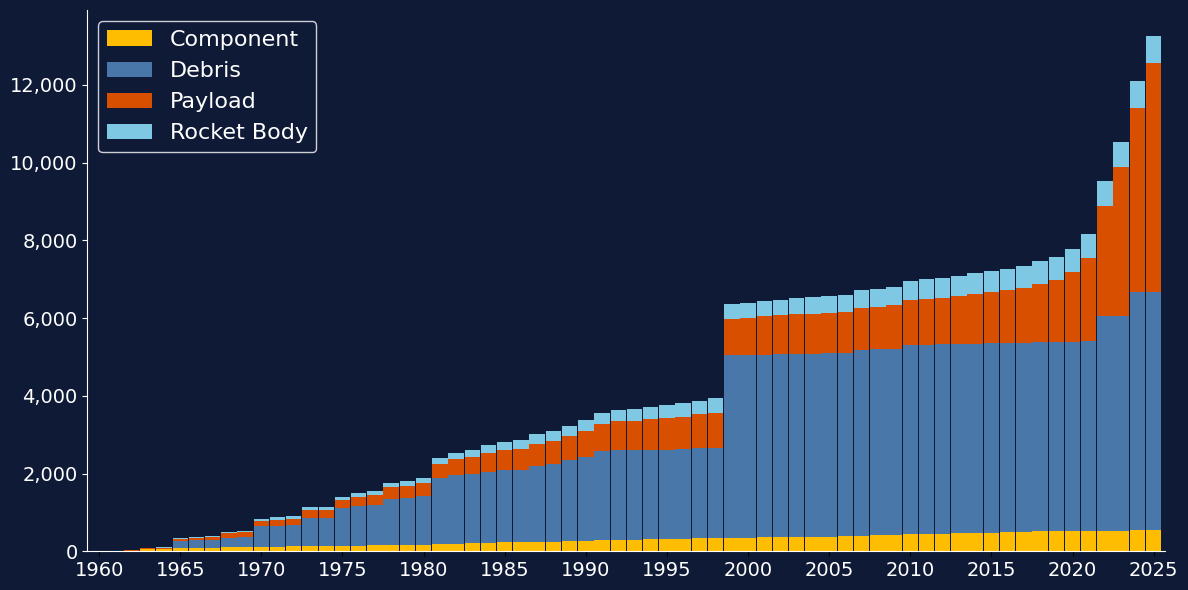

In [26]:
# Step 1: Filter for satellites currently in orbit
df_orbit = sdf_in_orbit[sdf_in_orbit["In Orbit"] == True].copy()

# Step 2: Extract launch year (assuming you have a 'Launch Date' column)
df_orbit["Year"] = pd.to_datetime(df_orbit["Launch Date"]).dt.year

# Step 3: Count objects by Year + Type
counts_by_year_type = (
    df_orbit.groupby(["Year", "Type"])
    .size()
    .reset_index(name="Count")
)

# Step 4: Pivot to wide format
pivot_counts = counts_by_year_type.pivot(index="Year", columns="Type", values="Count").fillna(0)

# Step 5: Compute cumulative counts over time
pivot_cumulative = pivot_counts.cumsum()

# Step 6: Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)

pivot_cumulative.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=foreground_colors[:len(pivot_cumulative.columns)],
    width=0.95
)

# Get the years as an array
years = pivot_cumulative.index.astype(int).to_numpy()

# Find positions where the year is a multiple of 5 (adjust start if needed)
mask = (years % 5 == 0)

# Positions on the axis are 0..len(years)-1
positions = np.arange(len(years))[mask]
tick_labels = years[mask]

ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, color="white", rotation=0, fontsize=14)
ax.set_xlabel("", labelpad=0)

# Styling (unchanged)
#ax.set_title("Cumulative In-Orbit Objects by Year and Type", color="white", fontsize=18, pad=20)
#ax.set_ylabel("Cumulative Number of Objects", color="white", fontsize=14)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis="y", colors="white", labelsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

legend = plt.legend( labelcolor="white", fontsize=16)
legend.get_frame().set_facecolor(bg)
legend.get_frame().set_edgecolor("white")

plt.tight_layout()
plt.show()


## Breakdown of objects by category (satellites, rocket bodies, debris).

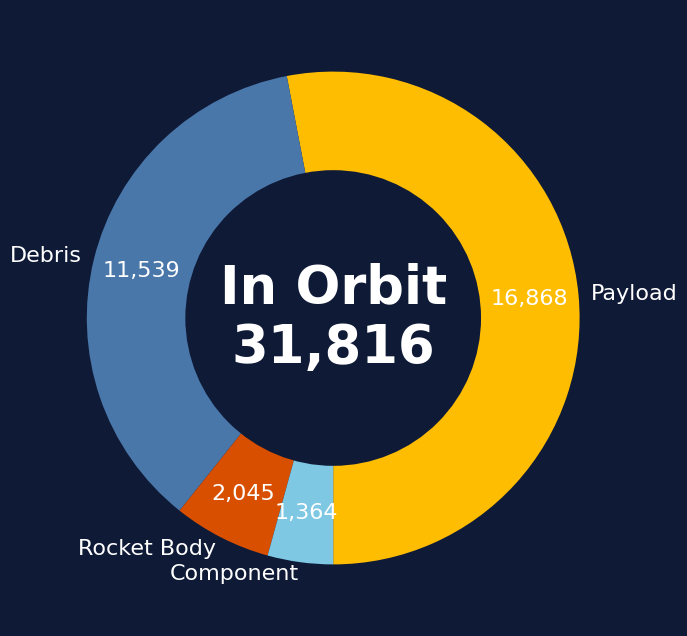

In [27]:
# Count by Type
type_counts = sdf_in_orbit['Type'].value_counts()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    #autopct='%1.1f%%',
    autopct=lambda pct: f"{int(round(pct/100.*type_counts.sum())):,}",  # show counts
    pctdistance=0.80,    # move counts outward
    labeldistance=1.05,    # move labels outward
    startangle=270,
    colors=foreground_colors[:len(type_counts)],
    textprops={'color': 'white', 'fontsize': 16}
)

# Make it a Donut Plot
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"In Orbit\n{type_counts.sum():,}", ha='center', va='center',
         color='white', fontsize=38, fontweight='bold')

plt.show()

## Payload categories (military, comms, scientific, etc.).

**Donut Chart**

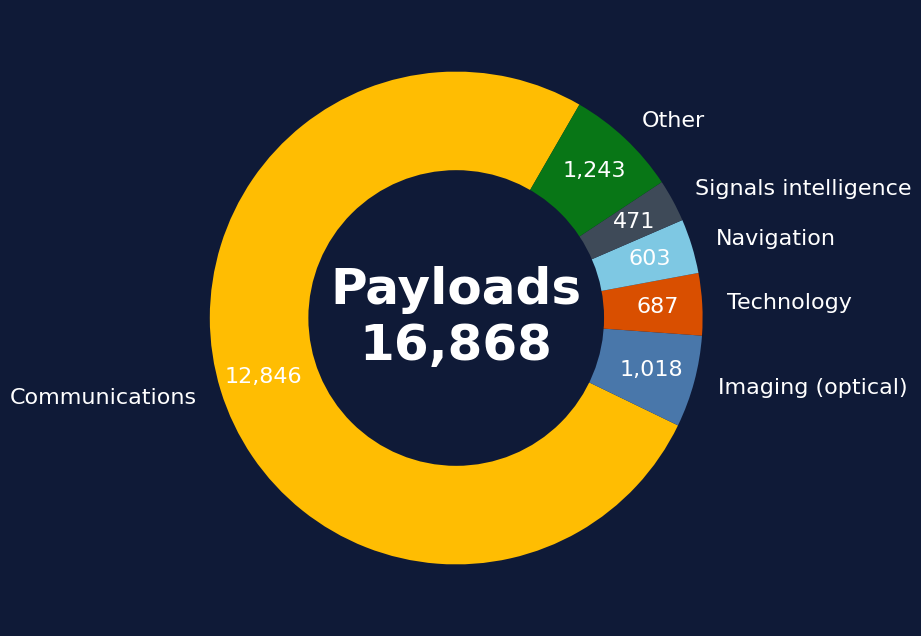

In [28]:
# Count by Category
category_counts_orbit = sdf_payloads_in_orbit['Primary Category'].value_counts()

# Keep top 5 and combine the rest into "Other"
top_n = 5
top_categories = category_counts_orbit[:top_n]
other_sum = category_counts_orbit[top_n:].sum()

# Append "Other" if there are remaining categories
if other_sum > 0:
    top_categories['Other'] = other_sum

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    top_categories,
    labels=top_categories.index,
    autopct=lambda pct: f"{int(round(pct/100.*top_categories.sum())):,}",  # show counts
    startangle=60,
    colors=foreground_colors[:len(top_categories)],
    textprops={'color': 'white', 'fontsize': 16},
    pctdistance=0.82,    # move counts outward
    labeldistance=1.1    # move labels outward
)
ax.set_aspect('equal')

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"Payloads\n{top_categories.sum():,}", ha='center', va='center',
         color='white', fontsize=36, fontweight='bold')

plt.show()


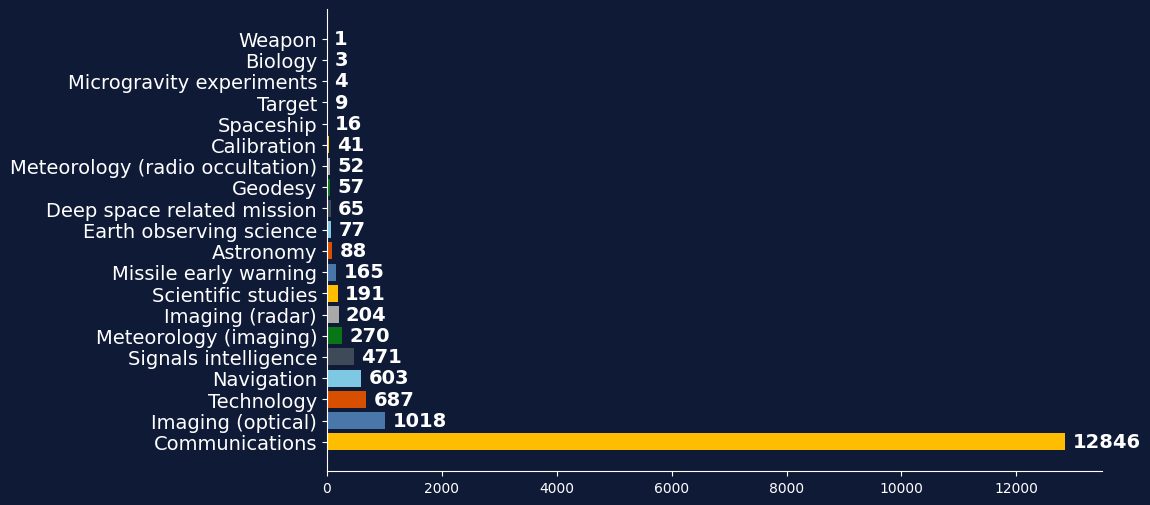

In [29]:
# Count by Category
category_counts_orbit = sdf_payloads_in_orbit['Primary Category'].value_counts()

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(10, 6), facecolor=bg)
ax.set_facecolor(bg)

# Horizontal bar chart
bars = ax.barh(
    category_counts_orbit .index,
    category_counts_orbit .values,
    color=foreground_colors[:len(category_counts_orbit )]
)

# Add counts on bars
for bar, count in zip(bars, category_counts_orbit .values):
    ax.text(
        count + max(category_counts_orbit .values)*0.01,  # small offset
        bar.get_y() + bar.get_height()/2,
        str(count),
        va='center',
        color='white',
        fontsize=14,
        fontweight='bold'
    )

# Style axes
ax.tick_params(axis='y', colors='white', labelsize=14)
ax.tick_params(axis='x', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.show()


## Type of Payload

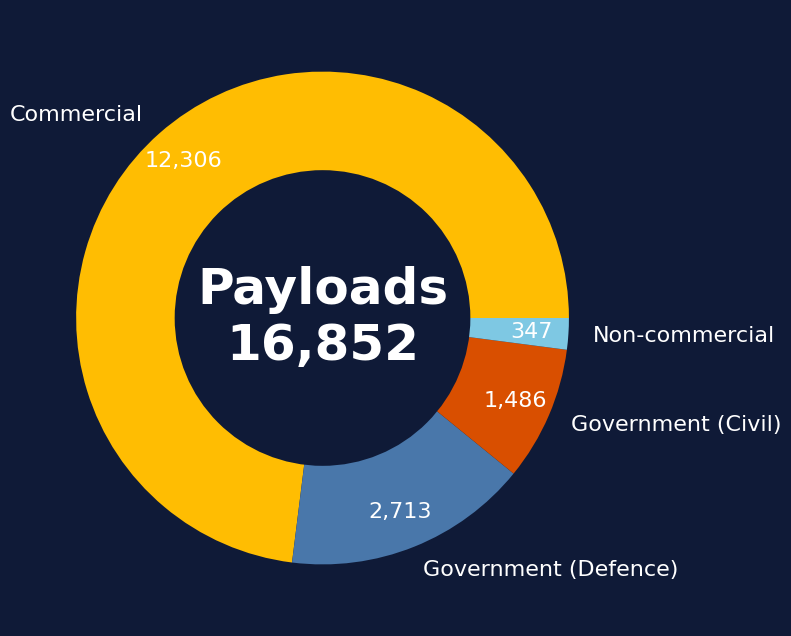

In [30]:
# Count by Class
class_counts_orbit = sdf_payloads_in_orbit['Class'].value_counts()

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    class_counts_orbit,
    labels=class_counts_orbit.index,
    autopct=lambda pct: f"{int(round(pct/100.*class_counts_orbit.sum())):,}",  # show counts
    startangle=0,
    colors=foreground_colors[:len(class_counts_orbit)],
    textprops={'color': 'white', 'fontsize': 16},
    pctdistance=0.85,    # move counts outward
    labeldistance=1.1    # move labels outward
)
ax.set_aspect('equal')

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"Payloads\n{class_counts_orbit.sum():,}", ha='center', va='center',
         color='white', fontsize=36, fontweight='bold')

plt.show()

## Operators and Origins - Masses

In [52]:

# Total mass of all satellites
total_mass = sdf_payloads_in_orbit["Mass"].sum() /1000
print("Total Mass:", total_mass, "metric tons")
print ()

# Total mass by country
mass_by_country = sdf_payloads_in_orbit.groupby("Country")["Mass"].sum()
print (mass_by_country.head(10))
print ()

# Total mass by category
mass_by_category = sdf_payloads_in_orbit.groupby("Primary Category")["Mass"].sum()
print (mass_by_category)


Total Mass: 12575.877274 metric tons

Country
Algeria        5633.0
Angola         3797.0
Argentina     15657.5
Australia     41718.5
Austria          18.0
Azerbaijan     6738.0
Bahrain           3.0
Bangladesh     3700.0
Belarus        5204.0
Bermuda        8099.0
Name: Mass, dtype: float64

Primary Category
Astronomy                            58754.220
Biology                                259.000
Calibration                           6363.000
Communications                     9058187.219
Deep space related mission           81922.000
Earth observing science              50717.600
Geodesy                              40838.000
Imaging (optical)                   801324.740
Imaging (radar)                     201640.000
Meteorology (imaging)               304069.000
Meteorology (radio occultation)       4403.000
Microgravity experiments               330.000
Missile early warning               238306.000
Navigation                          606026.000
Scientific studies             

### Overall Mass in Orbit

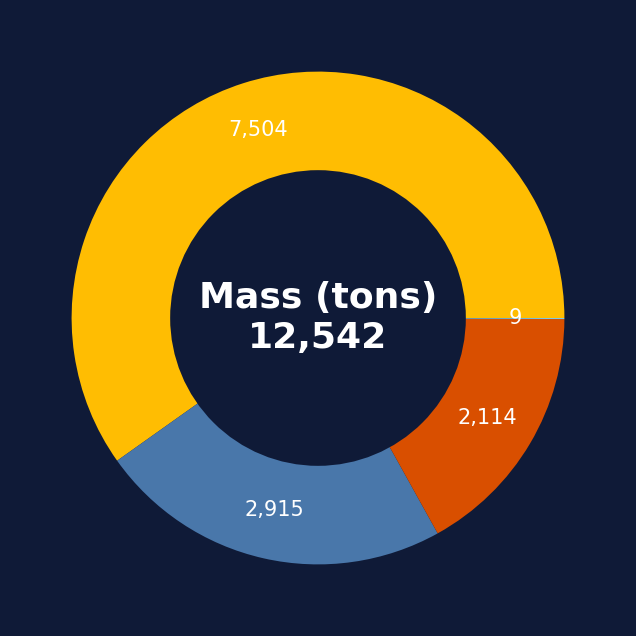

In [49]:
# Aggregate total mass by Class and convert to metric tons
class_mass_orbit = sdf_payloads_in_orbit.groupby("Class")["Mass"].sum().sort_values(ascending=False) /1000

# SCreate figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart of mass by Class
wedges, texts, autotexts = ax.pie(
    class_mass_orbit,
    #labels=class_mass_orbit.index,
    labels=None,
    autopct=lambda pct: f"{int(round(pct/100.*class_mass_orbit.sum())):,}",  # show mass values
    startangle=0,
    colors=foreground_colors[:len(class_mass_orbit)],
    textprops={'color': 'white', 'fontsize': 15},
    pctdistance=0.80,
    labeldistance=1.1
)
ax.set_aspect('equal')

# Make it a donut using background coloured circle
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (tons)\n{int(class_mass_orbit.sum()):,}",   # formatted with commas
    ha='center', va='center',
    color='white', fontsize=26, fontweight='bold'
)

plt.show()

### Overall Mass in Orbit (Top 5 Countries)

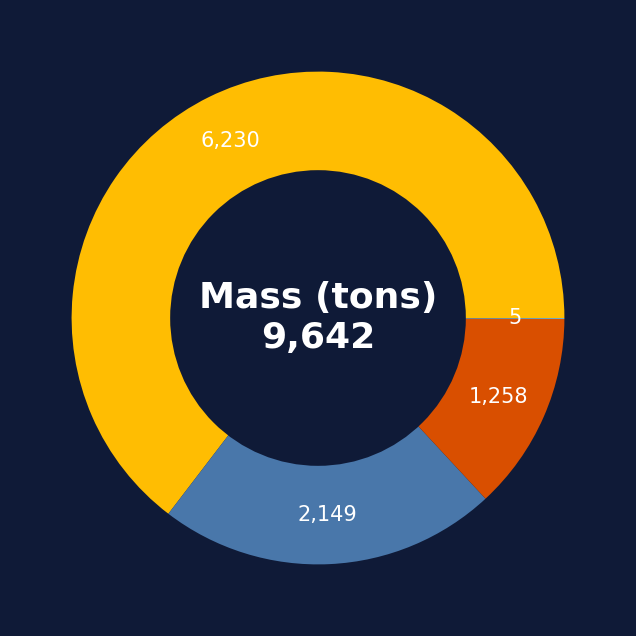

In [56]:
# Find top 5 countries by total mass
country_mass_orbit = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .sort_values(ascending=False)
)
top5_countries = country_mass_orbit.head(5).index

# Filter dataset to only those countries
df_top5 = sdf_payloads_in_orbit[sdf_payloads_in_orbit["Country"].isin(top5_countries)]

# Aggregate total mass by Class (within top 5 countries)
# Convert to metric tons
class_mass_top5 = (
    df_top5.groupby("Class")["Mass"] 
    .sum()
    .sort_values(ascending=False) /1000
)

# Create figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart of mass by Class (top 5 countries only)
wedges, texts, autotexts = ax.pie(
    class_mass_top5,
    labels=None,   # no text labels
    autopct=lambda pct: f"{int(round(pct/100.*class_mass_top5.sum())):,}",  # show mass values
    startangle=0,
    colors=foreground_colors[:len(class_mass_top5)],
    textprops={'color': 'white', 'fontsize': 15},
    pctdistance=0.80,
    labeldistance=1.1
)
ax.set_aspect('equal')

# Make it a donut using circle
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (tons)\n{int(class_mass_top5.sum()):,}",   # formatted with commas
    ha='center', va='center',
    color='white', fontsize=26, fontweight='bold'
)

plt.show()


Mass by Project / Program

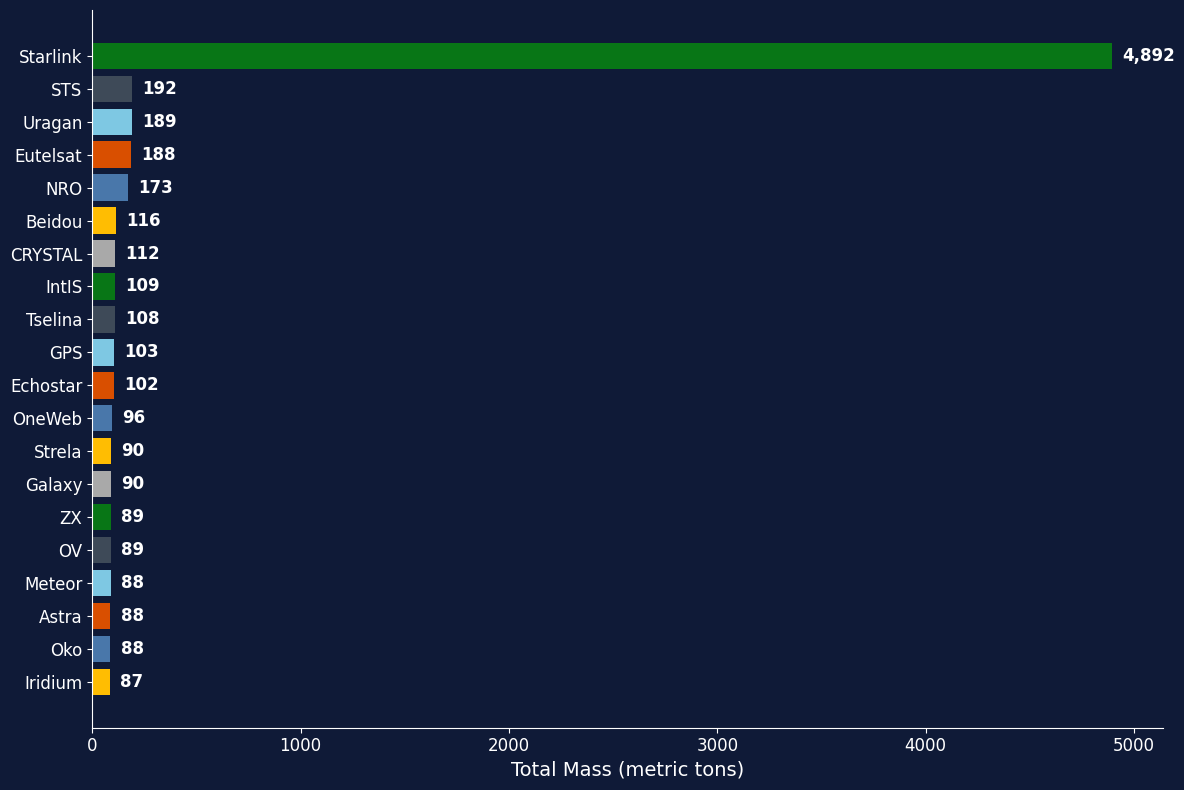

In [58]:
# Aggregate total mass by Program Root (Project), convert to tons
mass_by_program = (
    sdf_payloads_in_orbit.groupby("Program Root")["Mass"]
    .sum()
    .sort_values(ascending=True) 
    .tail(20) / 1000                   
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8), facecolor=bg)
ax.set_facecolor(bg)

# Plot horizontal bar chart
bars = ax.barh(
    mass_by_program.index,
    mass_by_program.values,
    color=foreground_colors[:len(mass_by_program)]
)

# Add labels at end of bars
for bar, value in zip(bars, mass_by_program.values):
    ax.text(
        value + max(mass_by_program.values)*0.01,   # small offset
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",                        # formatted with commas
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

# Style axes
#ax.set_title("Top 20 Programs by Total Satellite Mass", color="white", fontsize=18, pad=20)
ax.set_xlabel("Total Mass (metric tons)", color="white", fontsize=14)
ax.tick_params(axis="y", colors="white", labelsize=12)
ax.tick_params(axis="x", colors="white", labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()


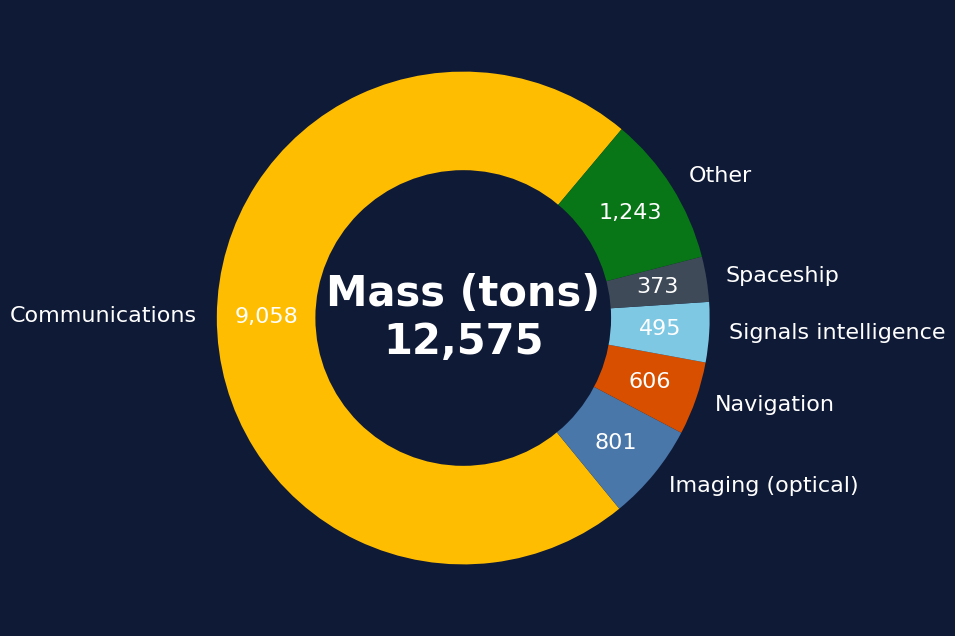

In [67]:
# Aggregate total mass by Primary Category, convert to tons
category_mass_orbit = (
    sdf_payloads_in_orbit.groupby("Primary Category")["Mass"]
    .sum()
    .sort_values(ascending=False) /1000
)

# Keep top 5 and combine the rest into "Other"
top_n = 5
top_categories = category_mass_orbit[:top_n]
other_sum = category_mass_orbit[top_n:].sum()

if other_sum > 0:
    top_categories["Other"] = other_sum

# Create figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart of mass by top 5 categories
wedges, texts, autotexts = ax.pie(
    top_categories,
    labels=top_categories.index,
    autopct=lambda pct: f"{int(round(pct/100.*top_categories.sum())):,}",  # show mass values
    startangle=50,
    colors=foreground_colors[:len(top_categories)],
    textprops={'color': 'white', 'fontsize': 16},
    pctdistance=0.8,
    labeldistance=1.08
)
ax.set_aspect('equal')

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (tons)\n{int(top_categories.sum()):,}",
    ha='center', va='center',
    color='white', fontsize=30, fontweight='bold'
)

plt.show()


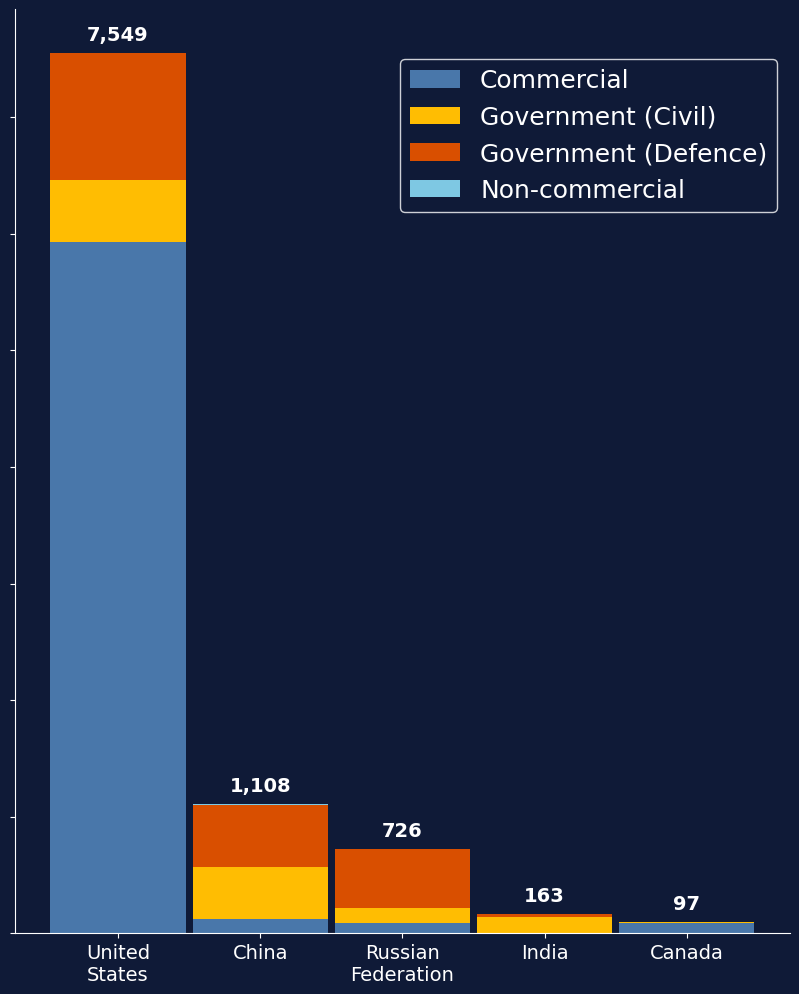

In [70]:
# Aggregate total mass per country
country_mass = sdf_payloads_in_orbit.groupby("Country")["Mass"].sum().sort_values(ascending=False)

# Select top 5 countries, then reverse order (smallest → largest)
top_countries = country_mass.head(5).sort_values(ascending=False).index

# Filter data for those countries
df_top = sdf_payloads_in_orbit[sdf_payloads_in_orbit["Country"].isin(top_countries)]

# Aggregate mass by Country + Class
mass_by_country_class = df_top.groupby(["Country", "Class"])["Mass"].sum().reset_index()
# Convert to tons
mass_by_country_class["Mass"] = mass_by_country_class["Mass"] / 1000

# Pivot for stacked bar chart
pivot_data = mass_by_country_class.pivot(index="Country", columns="Class", values="Mass").fillna(0)

# Reindex to enforce ascending order
pivot_data = pivot_data.loc[top_countries]

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 12), facecolor=bg)
ax.set_facecolor(bg)

# This chart requires custom foreground colour ordering to match with the other chart on the same page
# Attention to detail! :)

temp_foreground_colours = [
    graph_palette['foreground']['steelBlue'],
    graph_palette['foreground']['gold'],
    graph_palette['foreground']['burntOrange'],
    graph_palette['foreground']['skyBlue'],
]

pivot_data.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.95,
    color=temp_foreground_colours[:len(pivot_data.columns)]
)

# Compute totals for each column (country)
totals = pivot_data.sum(axis=1)
# Annotate totals above each bar
for i, total in enumerate(totals):
    ax.text(
        i, total + (0.01 * totals.max()),   # add 1% of max as vertical gap
        f"{total:,.0f}", 
        ha="center", va="bottom",
        color="white", fontsize=14, fontweight="bold"
    )

# Replace the offset text with custom string
ax.yaxis.get_offset_text().set_visible(False)   # hide the 1e7

# Replace spaces with newlines for stacked labels
labels = [label.replace(" ", "\n") for label in pivot_data.index]

# Apply labels with horizontal centering
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    color="white",
    fontsize=12,
    rotation=0,      # keep horizontal
    ha="center"      # center align under tick
)

ax.set_yticklabels([])   # hides the labels but keeps tick marks


ax.xaxis.label.set_visible(False)
ax.tick_params(axis="x", colors="white", labelsize=14, rotation=0)
ax.tick_params(axis="y", colors="white", labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

legend = plt.legend(labelcolor="white", fontsize=18, loc="upper right", bbox_to_anchor=(1, 0.96))
legend.get_frame().set_facecolor(bg)   # set legend background to bg
legend.get_frame().set_edgecolor("white")  
plt.show()


Didn't use this one

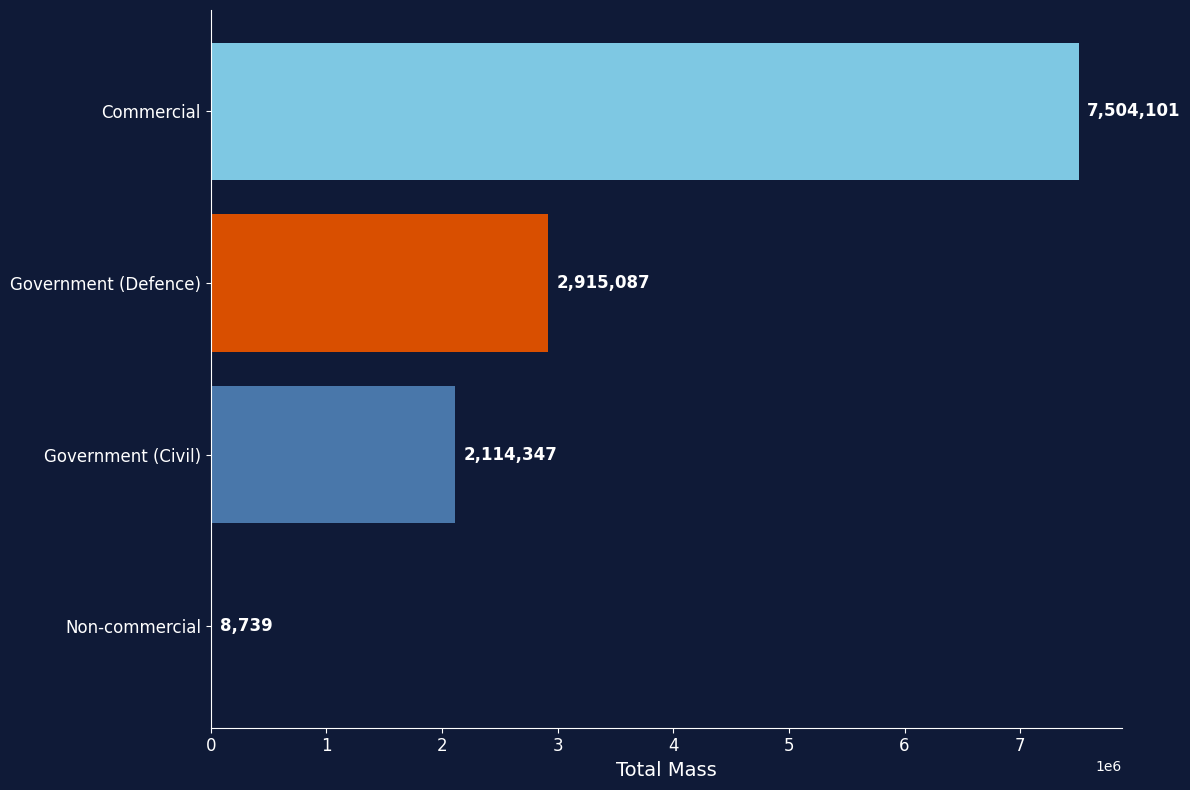

In [37]:
import matplotlib.pyplot as plt

# Step 1: Aggregate total mass by Class
mass_by_class = (
    sdf_payloads_in_orbit.groupby("Class")["Mass"]
    .sum()
    .sort_values(ascending=True)   # ascending so smallest at top
)

# Step 2: Create figure
fig, ax = plt.subplots(figsize=(12, 8), facecolor=bg)
ax.set_facecolor(bg)

# Step 3: Plot horizontal bar chart
bars = ax.barh(
    mass_by_class.index,
    mass_by_class.values,
    color=foreground_colors[:len(mass_by_class)]
)

# Step 4: Add labels at end of bars
for bar, value in zip(bars, mass_by_class.values):
    ax.text(
        value + max(mass_by_class.values)*0.01,   # small offset
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",                        # formatted with commas
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

# Step 5: Style axes
#ax.set_title("Total Satellite Mass by Class", color="white", fontsize=18, pad=20)
ax.set_xlabel("Total Mass", color="white", fontsize=14)
ax.tick_params(axis="y", colors="white", labelsize=12)
ax.tick_params(axis="x", colors="white", labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()


Connections between entities

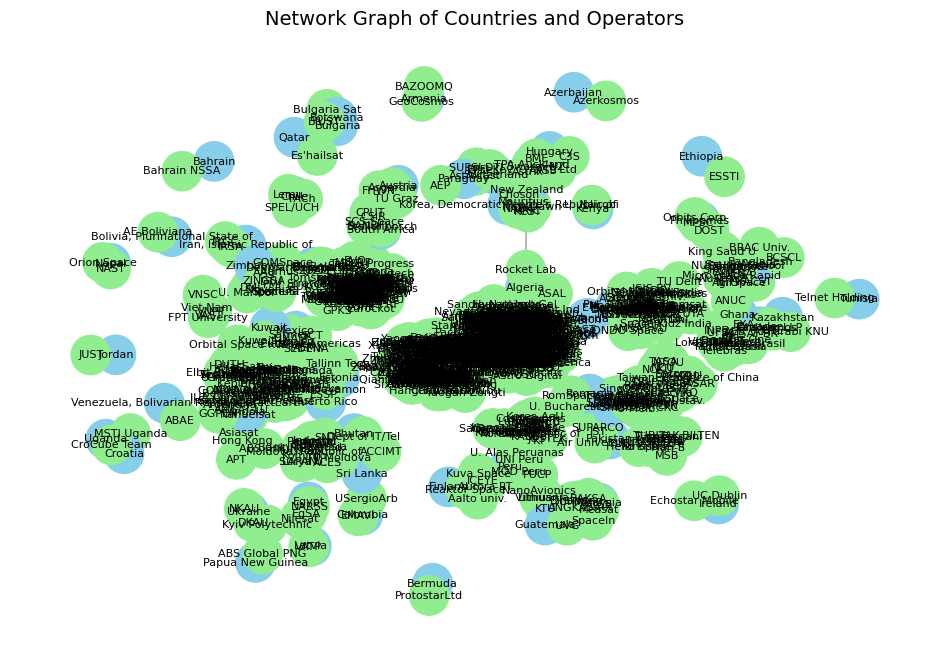

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

# Assume sdf is your dataframe

# Create a graph
G = nx.Graph()

# Add edges between Country and Operator Short Name
for _, row in sdf.iterrows():
    country = row['Country']
    operator = row['Operator Short Name']
    
    # Only add if both are not null
    if pd.notna(country) and pd.notna(operator):
        G.add_node(country, type='country')
        G.add_node(operator, type='operator')
        G.add_edge(country, operator)

# Define node colors based on type
color_map = []
for node in G.nodes(data=True):
    if node[1]['type'] == 'country':
        color_map.append('skyblue')   # Countries
    else:
        color_map.append('lightgreen') # Operators

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)  # Layout for readability
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=800)
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Network Graph of Countries and Operators", fontsize=14)
plt.axis('off')
plt.show()


In [39]:
import pandas as pd
import plotly.graph_objects as go

# Example: assume sdf is your dataframe
# Build a frequency matrix of Country vs Operator
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Get unique labels (countries + operators)
countries = matrix['Country'].unique().tolist()
operators = matrix['Operator Short Name'].unique().tolist()
labels = countries + operators

# Build source-target pairs
sources = []
targets = []
values = []

for _, row in matrix.iterrows():
    sources.append(labels.index(row['Country']))
    targets.append(labels.index(row['Operator Short Name']))
    values.append(row['count'])

# Create a Sankey diagram (works like a chord chart)
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=["skyblue"]*len(countries) + ["lightgreen"]*len(operators)
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    ))])

fig.update_layout(title_text="Chord-style Chart: Countries ↔ Operators", font_size=10)
fig.show()


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
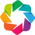

:Chord   [start,end]

In [40]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Example: build a dataframe of relationships
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Create edges for chord diagram
edges = []
for _, row in matrix.iterrows():
    edges.append((row['Country'], row['Operator Short Name'], row['count']))

# Convert to Holoviews dataset
chord = hv.Chord(edges)

# Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='source',
        node_color='index',
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('count')*0.05,  # scale edge thickness by count
    )
)

# Display in notebook / interactive environment
chord


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
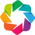

:Chord   [start,end]

In [41]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Step 1: Count satellites per Country-Operator pair
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Step 2: For each country, keep only the top 5 operators
top_ops = (
    matrix.groupby('Country', group_keys=False)
    .apply(lambda g: g.nlargest(5, 'count'))
)

# Step 3: Build edges for chord diagram
edges = [(row['Country'], row['Operator Short Name'], row['count']) 
         for _, row in top_ops.iterrows()]

# Step 4: Create chord diagram
chord = hv.Chord(edges)

# Step 5: Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='source',
        node_color='index',
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('count')*0.05,  # scale edge thickness by count
    )
)

chord


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
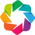

:Chord   [start,end]

In [42]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Step 1: Count satellites per Country-Operator pair
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Step 2: For each country, keep only the top 5 operators
top_ops = (
    matrix.groupby('Country', group_keys=False)
    .apply(lambda g: g.nlargest(5, 'count'))
)

# Step 3: Find the top 30 countries overall (by total satellites)
top_countries = (
    top_ops.groupby('Country')['count']
    .sum()
    .nlargest(30)
    .index
)

# Step 4: Filter to only those top 30 countries
filtered = top_ops[top_ops['Country'].isin(top_countries)]

# Step 5: Build edges for chord diagram
edges = [(row['Country'], row['Operator Short Name'], row['count']) 
         for _, row in filtered.iterrows()]

# Step 6: Create chord diagram
chord = hv.Chord(edges)

# Step 7: Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='source',
        node_color='index',
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('count')*0.05,
        width=1000,   # make the figure wider
        height=1000,  # make the figure taller
    )
)


chord


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
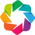

:Chord   [Country,Operator]   (launches)

In [43]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Step 1: Count launches per Country-Operator pair
launch_counts = (
    sdf.groupby(['Country', 'Operator Short Name'])['Launch Year']
    .count()
    .reset_index(name='launches')
)

# Step 2: For each country, keep only the top 5 operators by launches
top_ops = (
    launch_counts.groupby('Country', group_keys=False)
    .apply(lambda g: g.nlargest(5, 'launches'))
)

# Step 3: Find the top 30 countries overall (by total launches)
top_countries = (
    top_ops.groupby('Country')['launches']
    .sum()
    .nlargest(30)
    .index
)

# Step 4: Filter to only those top 30 countries
filtered = top_ops[top_ops['Country'].isin(top_countries)]

# Step 5: Rename column so Holoviews can use it cleanly
edges_df = filtered.rename(columns={'Operator Short Name': 'Operator'})

# Step 6: Create hv.Dataset with correct dimension names
dataset = hv.Dataset(edges_df, kdims=['Country', 'Operator'], vdims=['launches'])

# Step 7: Build chord diagram
chord = hv.Chord(dataset)

# Step 8: Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='Country',             # color edges by country
        node_color='index',               # color nodes by their label
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('launches')*0.05,  # thickness by launches
        width=1200,
        height=1200
    )
)

chord


On world map with weighted lines for connectivity


launch sites - map, blobs sized through frequency of use.

## Apogee and Perigee

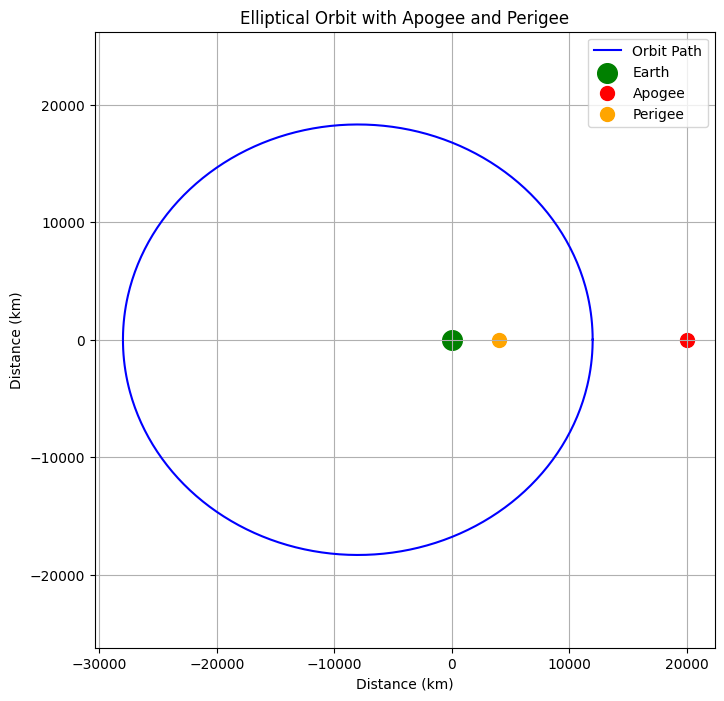

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Example orbital parameters (semi-major axis and eccentricity)
semi_major_axis = 20000   # km
eccentricity = 0.4        # 0 = circle, closer to 1 = very stretched

# Calculate semi-minor axis
semi_minor_axis = semi_major_axis * np.sqrt(1 - eccentricity**2)

# Parametric equation for ellipse
theta = np.linspace(0, 2*np.pi, 500)
x = semi_major_axis * np.cos(theta) - semi_major_axis * eccentricity  # shift Earth to one focus
y = semi_minor_axis * np.sin(theta)

# Apogee (farthest point) and Perigee (closest point)
apogee_x = semi_major_axis * (1 + eccentricity) - semi_major_axis * eccentricity
apogee_y = 0
perigee_x = semi_major_axis * (1 - eccentricity) - semi_major_axis * eccentricity
perigee_y = 0

# Plot
plt.figure(figsize=(8,8))
plt.plot(x, y, label='Orbit Path', color='blue')
plt.scatter(0, 0, color='green', s=200, label='Earth')  # Earth at focus
plt.scatter(apogee_x, apogee_y, color='red', s=100, label='Apogee')
plt.scatter(perigee_x, perigee_y, color='orange', s=100, label='Perigee')

# Labels and styling
plt.title('Elliptical Orbit with Apogee and Perigee')
plt.xlabel('Distance (km)')
plt.ylabel('Distance (km)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


ZeroDivisionError: float division by zero

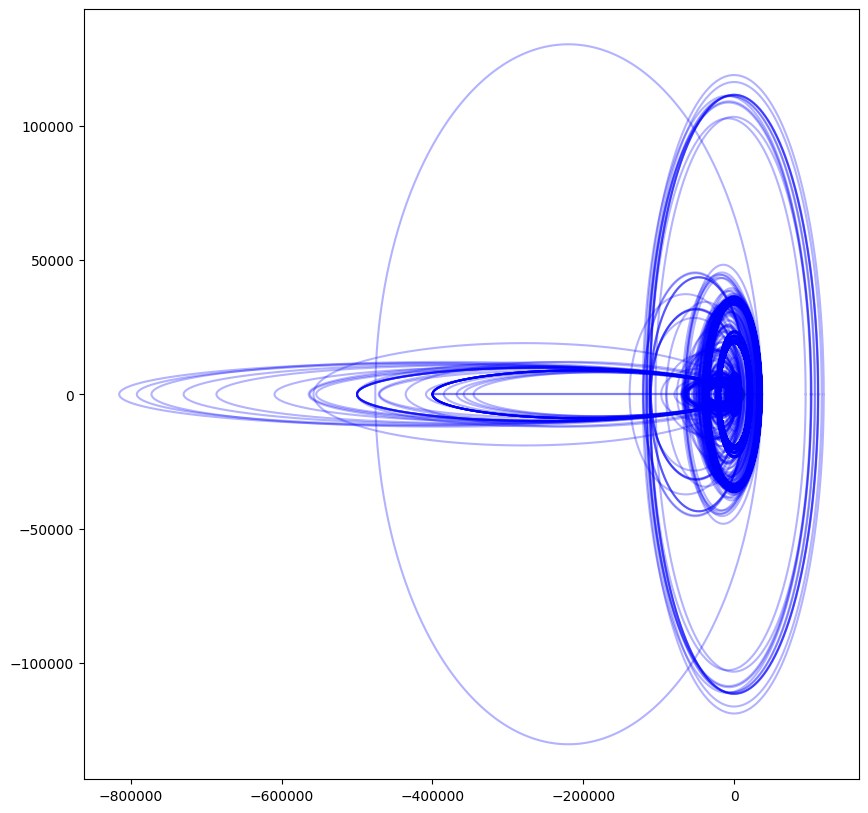

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Perigee'] = pd.to_numeric(payloads['Perigee'], errors='coerce')

# Drop rows with missing values
payloads = payloads.dropna(subset=['Apogee', 'Perigee'])

# Plot setup
plt.figure(figsize=(10,10))
plt.scatter(0, 0, color='green', s=200, label='Earth')  # Earth at focus

# Loop through each payload and plot its orbit
theta = np.linspace(0, 2*np.pi, 500)
for _, row in payloads.iterrows():
    apogee = row['Apogee']
    perigee = row['Perigee']
    
    # Semi-major axis and eccentricity
    a = (apogee + perigee) / 2
    e = (apogee - perigee) / (apogee + perigee)
    b = a * np.sqrt(1 - e**2)
    
    # Ellipse coordinates (Earth at one focus)
    x = a * np.cos(theta) - a * e
    y = b * np.sin(theta)
    
    plt.plot(x, y, alpha=0.3, color='blue')

plt.title('Orbits of Payloads Currently in Orbit')
plt.xlabel('Distance (km)')
plt.ylabel('Distance (km)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure Apogee is numeric
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads = payloads.dropna(subset=['Apogee'])

# Define bins of 50 km
bin_width = 5000
max_apogee = int(payloads['Apogee'].max()) + bin_width
bins = np.arange(0, max_apogee + bin_width, bin_width)

In [ ]:
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

payloads['Apogee'].sample(50)

Needed to add the earths radius to the apogee figures. I also went for a log scale because otherwise the animation was huge. This might need to be changed though to show a better picture.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# --- Filter for payloads only ---
payloads = sdf[sdf['Type'] == "Payload"].copy()

# --- Convert columns to proper types ---
payloads['Launch Date'] = pd.to_datetime(payloads['Launch Date'], errors='coerce')
payloads['Decay Date'] = pd.to_datetime(payloads['Decay Date'], errors='coerce')
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')

# --- Add Earth radius to apogee to get orbital radius ---
earth_radius = 6371  # km
payloads['OrbitRadius'] = payloads['Apogee'] + earth_radius

# --- Apply log10 transform for plotting ---
payloads['OrbitRadius_log'] = np.log10(payloads['OrbitRadius'].clip(lower=1))

# --- Define time range (weekly downsample for speed) ---
start_date = payloads['Launch Date'].min()
end_date = payloads['Decay Date'].max()
date_range = pd.date_range(start=start_date, end=end_date, freq='7D')

# --- Setup plot ---
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')
ax.set_xlim(-5, 5)   # log10 scale range
ax.set_ylim(-5, 5)

# Earth (scaled in log space)
earth_log_radius = np.log10(earth_radius)
earth = plt.Circle((0,0), earth_log_radius, color='blue')
ax.add_artist(earth)

# --- Orbit lines (draw once for all payloads) ---
for _, row in payloads.iterrows():
    if pd.notna(row['OrbitRadius_log']):
        orbit = plt.Circle((0,0), row['OrbitRadius_log'],
                           color='gray', fill=False, alpha=0.2, linewidth=0.5)
        ax.add_artist(orbit)

# Scatter for moving payloads
scat = ax.scatter([], [], s=10, c='red')

def init():
    scat.set_offsets(np.empty((0,2)))
    return scat,

def update(frame_date):
    active_objects = payloads[(payloads['Launch Date'] <= frame_date) &
                              ((payloads['Decay Date'].isna()) | (payloads['Decay Date'] > frame_date))]
    
    coords = []
    for _, row in active_objects.iterrows():
        if pd.isna(row['OrbitRadius_log']):
            continue
        days_since_launch = (frame_date - row['Launch Date']).days
        angle_deg = (days_since_launch * 360/365) % 360
        angle_rad = np.deg2rad(angle_deg)
        r = row['OrbitRadius_log']  # use log scale
        x = r * np.cos(angle_rad)
        y = r * np.sin(angle_rad)
        coords.append([x, y])
    
    coords = np.array(coords).reshape(-1, 2)
    scat.set_offsets(coords)
    ax.set_title(f"Date: {frame_date.date()}")
    return scat,

ani = animation.FuncAnimation(fig, update, frames=date_range,
                              init_func=init, blit=True, interval=100)

# --- Embed inline in Jupyter ---
HTML(ani.to_jshtml())


In [ ]:
from datetime import datetime

# Get the current date and time
current_datetime = datetime.now()
# Get the current timestamp
timestamp = str(current_datetime.timestamp()).split('.')[0]

# Save the animation
ani.save("orbits-" + timestamp + ".mp4", writer="ffmpeg", fps=30)

# Embed inline in Jupyter
#HTML(ani.to_jshtml())


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Launch Decade'] = pd.to_numeric(payloads['Launch Decade'], errors='coerce')
payloads = payloads.dropna(subset=['Apogee','Launch Decade'])

# Remove negative apogees
payloads = payloads[payloads['Apogee'] >= 0]

# Bucket apogee into 500 km ranges
bin_width = 250
payloads['Apogee_bin'] = (payloads['Apogee'] // bin_width) * bin_width

# Group by decade and apogee bin
grouped = payloads.groupby(['Launch Decade','Apogee_bin']).size().reset_index(name='count')

# Plot bubble chart
fig, ax = plt.subplots(figsize=(12,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    grouped['Launch Decade'],
    grouped['Apogee_bin'],
    s=grouped['count']*20,   # scale bubble size
    c=grouped['count'],
    cmap=cmap_orange_gold,
    alpha=0.5,
    edgecolors='white'
)

# White text and lines
ax.set_title('Payload Apogee Distribution by Decade (' + str(bin_width) + 'km bins)', color='white')
ax.set_xlabel('Launch Decade', color='white')
ax.set_ylabel('Apogee Altitude Bin (km)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

ax.grid(True, color='white', alpha=0.3)
plt.show()  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

payloads = sdf[(sdf['Type'] == 'Payload')]

# Convert dates
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')
sdf['Decay Date'] = pd.to_datetime(sdf['Decay Date'], errors='coerce')
sdf['Apogee'] = pd.to_numeric(sdf['Apogee'], errors='coerce')

# Define time range
start_date = sdf['Launch Date'].min()
end_date = sdf['Decay Date'].max()
# date_range = pd.date_range(start=start_date, end=end_date, freq='D')
# Define time range with weekly steps instead of daily
date_range = pd.date_range(start=start_date, end=end_date, freq='7D')


# Setup plot
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')
ax.set_xlim(-40000, 40000)
ax.set_ylim(-40000, 40000)

# Earth
earth = plt.Circle((0,0), 6371, color='blue')
ax.add_artist(earth)

# --- Orbit lines (draw once) ---
for _, row in sdf.iterrows():
    if pd.notna(row['Apogee']):
        orbit = plt.Circle((0,0), float(row['Apogee']), 
                           color='gray', fill=False, alpha=0.2, linewidth=0.5)
        ax.add_artist(orbit)

# Scatter for moving satellites
scat = ax.scatter([], [], s=10, c='red')

def init():
    scat.set_offsets(np.empty((0,2)))
    return scat,

def update(frame_date):
    active_objects = sdf[(sdf['Launch Date'] <= frame_date) &
                         ((sdf['Decay Date'].isna()) | (sdf['Decay Date'] > frame_date))]
    
    coords = []
    for _, row in active_objects.iterrows():
        if pd.isna(row['Apogee']):
            continue
        days_since_launch = (frame_date - row['Launch Date']).days
        angle_deg = (days_since_launch * 360/365) % 360
        angle_rad = np.deg2rad(angle_deg)
        r = float(row['Apogee'])
        x = r * np.cos(angle_rad)
        y = r * np.sin(angle_rad)
        coords.append([x, y])
    
    coords = np.array(coords).reshape(-1, 2)
    scat.set_offsets(coords)
    ax.set_title(f"Date: {frame_date.date()}")
    return scat,

ani = animation.FuncAnimation(fig, update, frames=date_range,
                              init_func=init, blit=True, interval=50)


from IPython.display import HTML
HTML(ani.to_jshtml())


### More fun stuff below :)

In [ ]:
avg_lifetime = sdf[sdf['Type'].str.startswith('P', na=False)].groupby('Country')['Lifespan Years'].mean().reset_index()
avg_lifetime.columns = ['Country', 'AvgLifetime']
avg_lifetime = avg_lifetime.sort_values('AvgLifetime', ascending=False).head(20)

In [ ]:
plt.figure(figsize=(12, 10))
plt.bar(avg_lifetime['Country'], avg_lifetime['AvgLifetime'], color=foreground_colors)
plt.xlabel('Average Lifetime (Years)')
plt.title('Average Object Lifetime by Country')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime

df = sdf_in_orbit.copy()

df["start"] = pd.to_datetime(df["Launch Date"])
df["end"] = pd.to_datetime(df["Decay Date"])  # or Deactivation/Reentry/Last Contact
df["still_active"] = df["In Orbit"]

# If active, use "today" as placeholder end for duration and mark censored
today = pd.Timestamp.today()
df["observed_end"] = df["end"].fillna(today)
df["duration_years"] = (df["observed_end"] - df["start"]).dt.days / 365.25
df["event_observed"] = (~df["still_active"]).astype(int)  # 1=ended, 0=censored


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, x="Type", y="duration_years", inner="quartile", cut=0
)
sns.stripplot(
    data=df, x="Type", y="duration_years", color="black", alpha=0.1, jitter=0.25
)
plt.ylabel("Lifespan (years)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.title("Lifespan distribution by type")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, x="Primary Category", y="duration_years", inner="quartile", cut=0
)
sns.stripplot(
    data=df, x="Primary Category", y="duration_years", color="black", alpha=0.1, jitter=0.25
)
plt.ylabel("Lifespan (years)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.title("Lifespan distribution by type")
plt.tight_layout()
plt.show()


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 6))
for t, g in df.groupby("Type"):
    kmf.fit(g["duration_years"], event_observed=g["event_observed"], label=t)
    kmf.plot(ci_show=True)

plt.ylabel("Survival probability (still active)")
plt.xlabel("Years since launch")
plt.title("Kaplan–Meier survival curves by type")
plt.legend(title="Type")
plt.tight_layout()
plt.show()


In [ ]:
summary = []
for t, g in df.groupby("Type"):
    kmf.fit(g["duration_years"], event_observed=g["event_observed"])
    summary.append({
        "Type": t,
        "Median lifespan (years)": kmf.median_survival_time_,
        "n": len(g),
        "censored_%": 100 * (1 - g["event_observed"].mean())
    })

summary_df = pd.DataFrame(summary).sort_values("Median lifespan (years)", ascending=False)


In [ ]:


# Drop rows with missing values in hierarchy columns
sdf_payloads_in_orbit = sdf_payloads_in_orbit.dropna(subset=['Country', 'Class'])

# Aggregate counts for clarity
agg_df = sdf_payloads_in_orbit.groupby(['Country', 'Class']).size().reset_index(name='Count')


# Step 5: Create sunburst chart
fig = px.sunburst(
    agg_df,
    path=['Class', 'Country'],
    values='Count',
    title='Top 20 Countries by Object Volume (Grouped by Class)',
    color='Country'
)

fig.update_layout(
    width=1200,   # Increase width (default is ~700)
    height=800,   # Increase height (default is ~450)
    margin=dict(t=50, l=25, r=25, b=25)
)
fig.show()


## Rubbish Charts :-)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data: only keep top 5 categories + Other
category_counts_orbit = sdf_payloads_in_orbit['Primary Category'].value_counts()
top_n = 5
top_categories = category_counts_orbit.index[:top_n]

# Mark all others as "Other"
sdf_mass = sdf_payloads_in_orbit.copy()
sdf_mass['Category Group'] = sdf_mass['Primary Category'].where(
    sdf_mass['Primary Category'].isin(top_categories),
    other='Other'
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)

# Boxplot of Mass by Category Group
sns.boxplot(
    data=sdf_mass,
    x='Mass',
    y='Category Group',
    palette=foreground_colors[:len(sdf_mass['Category Group'].unique())],
    ax=ax
)

# Style axes
ax.set_title("Satellite Mass Distribution by Category (Top 5 + Other)",
             color='white', fontsize=18, pad=20)
ax.tick_params(axis='x', colors='white', labelsize=12)
ax.tick_params(axis='y', colors='white', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate: average mass per Type
mass_by_type = sdf_payloads_in_orbit.groupby("Class")["Mass"].mean().sort_values(ascending=False)

# Convert to DataFrame for heatmap
heatmap_data = mass_by_type.to_frame().T  # transpose so Type are columns

# Create figure
fig, ax = plt.subplots(figsize=(14, 6), facecolor=bg)
ax.set_facecolor(bg)

# Heatmap
sns.heatmap(
    heatmap_data,
    cmap=sns.color_palette(foreground_colors, as_cmap=True),
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar=True,
    ax=ax
)

# Style
ax.set_title("Average Satellite Mass by Type", color="white", fontsize=18, pad=20)
ax.tick_params(axis="x", colors="white", labelsize=12, rotation=45)
ax.tick_params(axis="y", colors="white", labelsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Aggregate total mass by Country
mass_by_country = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .reset_index()
)

# Sort for clarity
mass_by_country = mass_by_country.sort_values("Mass", ascending=False)

# Treemap
fig = px.treemap(
    mass_by_country,
    path=["Country"],
    values="Mass",
    color="Mass",
    color_continuous_scale=foreground_colors,  # use your palette
)

# Style background
fig.update_layout(
    paper_bgcolor=bg,
    plot_bgcolor=bg,
    font=dict(color="white")
)

fig.show()


In [ ]:
import geopandas as gpd

# Load the built-in world dataset
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Inspect columns
print(world.columns)
# ['pop_est', 'continent', 'name', 'iso_a3', 'gdp_md_est', 'geometry']

# Example: create a mapping from country name to continent
country_to_continent = dict(zip(world["name"], world["continent"]))

# Now you can map your dataframe's Country column
df["Continent"] = df["Country"].map(country_to_continent)



In [ ]:
import pandas as pd
import plotly.express as px

# Step 1: Aggregate total mass per country
mass_by_country = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .reset_index()
)

# Step 2: Build choropleth map
fig = px.choropleth(
    mass_by_country,
    locations="Country",          # country names
    locationmode="country names", # match by name
    color="Mass",                 # shading by total mass
    color_continuous_scale=[graph_palette['foreground']['gold'], graph_palette['foreground']['steelBlue']],  # your palette
    title="Total Satellite Mass by Country"
)

# Step 3: Style background
fig.update_layout(
    paper_bgcolor=bg,
    plot_bgcolor=bg,
    font=dict(color="white"),
    geo=dict(bgcolor=bg)
)

fig.show()


In [ ]:
grouped = sdf.groupby(['Launch Year', 'In Orbit']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

In [ ]:
grouped = sdf.groupby(['Launch Year',  'In Orbit']).size().unstack(fill_value=0).sort_index()
#'Type',
grouped.plot(kind='line', marker='o', figsize=(12, 6), color=foreground_colors)
plt.title('Objects Added per Year by Typeription')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

In [ ]:



# Plot both series
plt.figure(figsize=(12, 6))
plt.plot(cumulative_by_year.index, cumulative_by_year.values, label='Cumulative In Orbit', color='blue', marker='o')
plt.plot(launches_by_year.index, launches_by_year.values, label='Launched per Year', color='orange', marker='o')

# Customise chart
plt.title('Launches per Year vs Cumulative Objects In Orbit')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# NEED TO FINISH THIS SECTION

Idea notes:

Graphs to Draw

Disteibution curves

Life time of object in years vs type


—. Box plot 
ployly interactive box plot

Bar charts

X = top 10 countries for satellites
Y = Counts of 


Per top ten countries (and second chart for owner), by year, violin plot for active or not?

Objects which appear and disappear in the same year. (< 12 months)

How much debris is still in orbit? 
Percentage of the debris that belongs to a given country / owner.

Parent… if there is no parent, copy owner?

Class and Categories



Presentation

- Discuss the Issue
- Discuss the types of satellite out there - class and category

Life span… 
By company — 
By type and class


Sunburst. — country… then class/.

- 


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 10 countries by satellite count
top_countries = sdf['Country Code'].value_counts().nlargest(10).index

# Filter for top countries
filtered_df = sdf[sdf['Country Code'].isin(top_countries)]

# Group by CountryCode and Class
grouped = filtered_df.groupby(['Country Code', 'Class']).size().reset_index(name='Count')

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x='Country Code',
    y='Count',
    hue='Class',
    palette='Set2'
)

# Customize the plot
plt.title('Satellite Class Distribution for Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Satellites')
plt.xticks(rotation=45)
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

